# MECH 309: Assignment 5, Question 1

_Cagri Arslan_

March 12, 2025

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [27]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from loadData import load_calibration_data

plt.style.use("bmh") # plotting style

# a)

Using each data pair $(v_i, y_i)$ and the model
$$
y(v)=a+bv^c,
$$
we have
$$
y_i = a + b v_i^c, \qquad i=1,2,\dots,n.
$$

Let
$$
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2\\
x_3
\end{bmatrix}
=
\begin{bmatrix}
a\\
b\\
c
\end{bmatrix}.
$$

Then the nonlinear least-squares problem
$$
\min_{\mathbf{x}} J(\mathbf{x})=\frac{1}{2}\|\mathbf{b}-\mathbf{f}(\mathbf{x})\|_2^2
$$
has

$$
\mathbf{b}=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix},
\qquad
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
x_1 + x_2 v_1^{x_3}\\
x_1 + x_2 v_2^{x_3}\\
\vdots\\
x_1 + x_2 v_n^{x_3}
\end{bmatrix}.
$$

Equivalently, since $\mathbf{x}=[a\ b\ c]^T$,
$$
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
a+bv_1^c\\
a+bv_2^c\\
\vdots\\
a+bv_n^c
\end{bmatrix}.
$$

#

From part (a), define
$$
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
f_1(\mathbf{x})\\
f_2(\mathbf{x})\\
\vdots\\
f_n(\mathbf{x})
\end{bmatrix}
=
\begin{bmatrix}
a+bv_1^c\\
a+bv_2^c\\
\vdots\\
a+bv_n^c
\end{bmatrix},
\qquad
\mathbf{x}=
\begin{bmatrix}
a\\
b\\
c
\end{bmatrix}.
$$

The Jacobian matrix is
$$
\mathbf{A}(\mathbf{x})=\frac{\partial \mathbf{f}}{\partial \mathbf{x}}
=
\begin{bmatrix}
\frac{\partial f_1}{\partial a} & \frac{\partial f_1}{\partial b} & \frac{\partial f_1}{\partial c}\\
\frac{\partial f_2}{\partial a} & \frac{\partial f_2}{\partial b} & \frac{\partial f_2}{\partial c}\\
\vdots & \vdots & \vdots\\
\frac{\partial f_n}{\partial a} & \frac{\partial f_n}{\partial b} & \frac{\partial f_n}{\partial c}
\end{bmatrix}.
$$

Since
$$
f_i(\mathbf{x})=a+bv_i^c,
$$
we get
$$
\frac{\partial f_i}{\partial a}=1,
\qquad
\frac{\partial f_i}{\partial b}=v_i^c,
\qquad
\frac{\partial f_i}{\partial c}=b\,v_i^c\ln(v_i).
$$

Therefore,
$$
\mathbf{A}(\mathbf{x})=
\begin{bmatrix}
1 & v_1^c & b\,v_1^c\ln(v_1)\\
1 & v_2^c & b\,v_2^c\ln(v_2)\\
\vdots & \vdots & \vdots\\
1 & v_n^c & b\,v_n^c\ln(v_n)
\end{bmatrix}.
$$

# c)
We consider the nonlinear least squares problem of the form:

$$
\mathbf{f}(\mathbf{x})=\mathbf{b}
$$

We solve this using:

$$
\mathbf{A}(\overline{\mathbf{x}})^{\mathsf{T}}\mathbf{A}(\overline{\mathbf{x}})\delta\mathbf{x}=\mathbf{A}(\overline{\mathbf{x}})^{\mathsf{T}}(\mathbf{b}-\mathbf{f}(\overline{\mathbf{x}}))
$$

As this is a nonlinear least squares problem, we solve it iteratively with the Gauss-Newton algorithm as such:

$$
\mathbf{A}^{\mathsf{T}}_{i}\mathbf{A}_{i}\delta\mathbf{x}_{i}=\mathbf{A}^{\mathsf{T}}_{i}(\mathbf{b}-\mathbf{f}({\mathbf{x}}_{i})) \\
\mathbf{x}_{i+1} = \mathbf{x}_{i} + \delta \mathbf{x}_{i}
$$

Visually observing the data pairs $(v_i, y_i)$ from ```loadData.py```, we notice some sort of power law relationship with an exponent between 0 and 1. Simply, it looks like a square-root function. Therefore, our initial "guess" is $\mathbf{x}_{0}$ is $\mathbf{x}=[0,\ 1,\ 0.5]^T$. This represents the simple square root function of $y=\sqrt{v}$. The GN algorithm will iteratively adjust the vertical displacement $a$, scaling factor $b$, and exponent $c$.

We iterate until the relative residual is below some threshold $\epsilon$. The code to compute this specific power-law fit using the Gauss-Newton algorithm is below:

In [ ]:
def GN_solve(y_data, v_data, x=None, epsilon=1e-12, max_iter = 1000000):

    if x is None:
        x = np.array([0.0, 1.0, 0.5], dtype=float)   # 1D, shape (3,)

    y = y_data
    v = v_data

    counter = 0
    dx = np.array([1.0]) # Initial value

    while np.linalg.norm(dx, ord = 2) > epsilon and counter < max_iter:
        a = x[0]
        b = x[1]
        c = x[2]

        f = np.array(a + b * v ** c)
        A = np.column_stack((
            np.ones_like(v),
            v**c,
            b * (v**c) * np.log(v)
            ))
        
        lhs = A.T @ A
        rhs = A.T @ (y - f)

        dx = np.linalg.solve(lhs, rhs)

        x = x + dx

        counter += 1
        # print(counter, np.linalg.norm(dx, ord = 2))

    if counter == max_iter:
        print(f"Warning! Solution did not converge, residual is {dx}")

    return x, counter

We then run this on the hot-wire anemometer dataset

In [35]:
v_data, y_data = load_calibration_data()

x, counter = GN_solve(y_data, v_data)

a, b, c = x
y_fit = a + b * v_data**c
rmse = np.sqrt(np.mean((y_data - y_fit)**2))

print("Gauss-Newton fit results")
print("------------------------")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"Converged in {counter} iterations")
print(f"RMSE = {rmse:.6f}")

Gauss-Newton fit results
------------------------
a = 4.251882
b = 2.904641
c = 0.346014
Converged in 10 iterations
RMSE = 0.009670


As presented, the Gauss-Newton algorithm converged in 10 iterations (although this is a function of the chosen tolerance $\epsilon$). The resultant matrix $\mathbf{x}$ is:

$$
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2\\
x_3
\end{bmatrix}
=
\begin{bmatrix}
a\\
b\\
c
\end{bmatrix}
\approx
\begin{bmatrix}
4.252\\
2.905\\
0.346
\end{bmatrix}.
$$

And so the fitted curve is:

$$
y(v) = 4.252 + 2.905v^{0.346}
$$

# d)

We plot the fitted curve determined through the GN algorithm alongside the actual data points below.

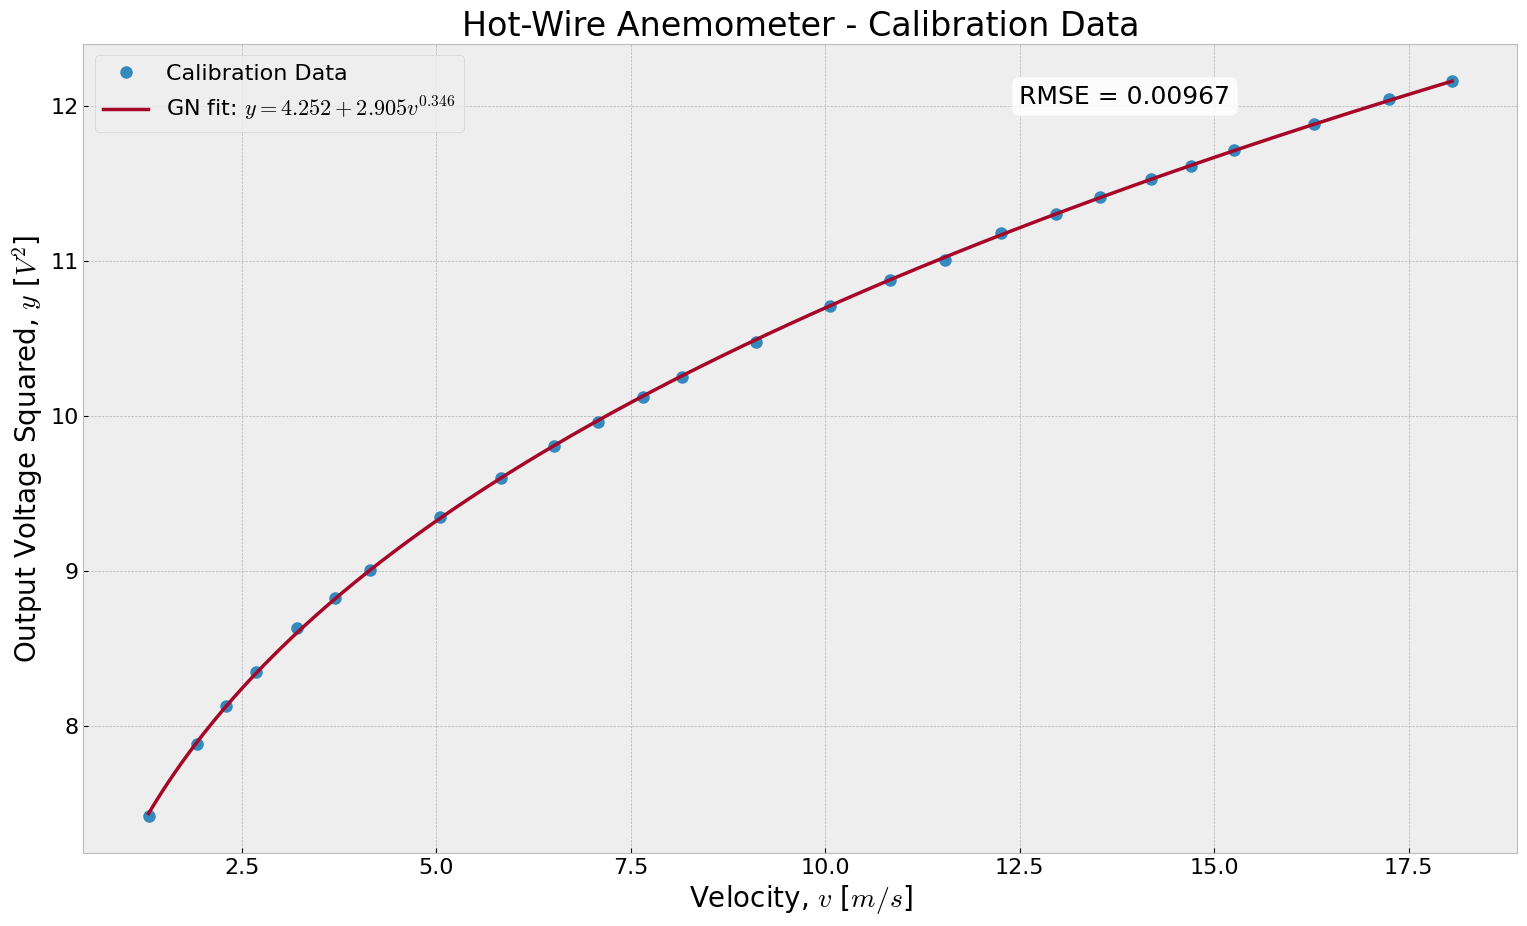

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Solve for fitted parameters
x_fit, counter = GN_solve(y_data, v_data)
a, b, c = x_fit

# Predictions at data points and RMSE
y_fit_data = a + b * v_data**c
rmse = np.sqrt(np.mean((y_data - y_fit_data)**2))

# Smooth curve for plotting
v_plot = np.linspace(np.min(v_data), np.max(v_data), 400)
y_plot = a + b * v_plot**c

fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5, forward=True)

ax.set_title(r"Hot-Wire Anemometer - Calibration Data", fontsize=24)
ax.set_xlabel(r"Velocity, $v$ [$m/s$]", fontsize=20)
ax.set_ylabel(r"Output Voltage Squared, $y$ [$V^2$]", fontsize=20)

ax.plot(v_data, y_data, "o", markersize=8, label="Calibration Data")
ax.plot(
    v_plot,
    y_plot,
    "-",
    linewidth=2.5,
    label=rf"GN fit: $y = {a:.3f} + {b:.3f}v^{{{c:.3f}}}$"
)

ax.text(
    0.80, 0.95,
    rf"RMSE = {rmse:.5f}",
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

ax.tick_params(axis="both", labelsize=16)
ax.legend(loc="upper left", fontsize=16)

plt.show()

Visually, the fitted curve very closely matches the empirical data. Likewise, a very small RMSE of 0.00967 is realized, indiciating a very good fit. This implies that the power-law model is an accurate model to relate velocity to output voltage squared.